### Learning Objectives
By the end of this lesson, students will be able to:
- Import CSV files with default options (`pd.read_csv`)
- Handle files with **extra header/metadata rows** using `skiprows`
- Parse dates with `parse_dates`
- Enforce column types with `dtype`
- Read Excel sheets using `pd.read_excel` with a specific `sheet_name` and `header` row
- Inspect DataFrame structure using `.info()`

> **Note: If you don't have `pandas` package installed, please install first.**

## **Reading Files with pandas**

This section shows how to read CSV and Excel files using **pandas**.

**Files used in examples**
- `stock_prices.csv` (simple CSV)
- `financials.csv` (CSV with 4 metadata rows to skip, typed columns, and parsed dates)
- `financial_data.xlsx` (Excel sheet named **Quarterly**, with the header on the 4th row)

In [ ]:
# Use this to copy files from a public Google Drive folder into Colab.
# If the files are already present in /MLF, you can skip this cell.
!pip -q install -U gdown
!gdown --folder "https://drive.google.com/drive/folders/1ilUQMPIJK5vjosUMC3FiSdZ1ORhzYTCQ?usp=sharing" -O /MLF/

Retrieving folder contents
Processing file 19tXpAmhVHwdSCn0WxsbEvQZd-FHIC_lx air-quality.csv
Processing file 1HW9v-j8lMVzvZU1Q-RjmJOIr7qhI1xX4 financial_data.xlsx
Processing file 1lbRta6xbsBZoBUxtvyvI62jK-tYHW-ye financials.csv
Processing file 1FER5AhyaBub_iPy1-A4U9Ws19YXdxmY8 stock_prices.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=19tXpAmhVHwdSCn0WxsbEvQZd-FHIC_lx
To: /MLF/MLF/air-quality.csv
100% 4.40k/4.40k [00:00<00:00, 15.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HW9v-j8lMVzvZU1Q-RjmJOIr7qhI1xX4
To: /MLF/MLF/financial_data.xlsx
100% 5.25k/5.25k [00:00<00:00, 18.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lbRta6xbsBZoBUxtvyvI62jK-tYHW-ye
To: /MLF/MLF/financials.csv
100% 350/350 [00:00<00:00, 1.68MB/s]
Downloading...
From: https://drive.google.com/uc?id=1FER5AhyaBub_iPy1-A4U9Ws19YXdxmY8
To: /MLF/MLF/stock_prices.csv
100% 1.09k/1.09k 

# **Importing and Cleaning Financial Data using Python**

In [ ]:
# Import pandas
import pandas as pd

In [ ]:
# Basic CSV import
stock_data = pd.read_csv('/MLF/MLF/stock_prices.csv')

# Print dataset
print(stock_data)

          Date Ticker    Open    High     Low   Close    Volume
0   2025-08-25   AAPL  150.27  151.96  149.66  150.50  20738466
1   2025-08-26   AAPL  150.13  150.58  148.27  150.36  20171368
2   2025-08-27   AAPL  151.13  151.19  150.99  151.01  19884351
3   2025-08-28   AAPL  151.57  153.95  150.51  152.53  19698896
4   2025-08-29   AAPL  151.43  152.84  150.61  152.30  18521478
5   2025-08-30   AAPL  151.78  152.17  150.56  152.06  19280155
6   2025-08-31   AAPL  153.13  154.79  152.92  153.64  19539361
7   2025-09-01   AAPL  154.56  154.94  152.45  154.41  21057122
8   2025-09-02   AAPL  153.48  154.54  152.16  153.94  20343618
9   2025-09-03   AAPL  153.77  154.77  153.58  154.48  18236959
10  2025-08-25   MSFT  150.08  150.69  149.86  150.32  20097077
11  2025-08-26   MSFT  149.85  151.48  149.49  149.94  20968644
12  2025-08-27   MSFT  148.71  149.30  147.23  149.26  19297946
13  2025-08-28   MSFT  149.28  151.44  148.76  149.87  19672337
14  2025-08-29   MSFT  151.31  153.93  1

In [ ]:
# See the Structure of the data
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    20 non-null     object 
 1   Ticker  20 non-null     object 
 2   Open    20 non-null     float64
 3   High    20 non-null     float64
 4   Low     20 non-null     float64
 5   Close   20 non-null     float64
 6   Volume  20 non-null     int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 1.2+ KB


In [ ]:
# Advanced CSV import
financials = pd.read_csv(
    '/MLF/MLF/financials.csv',
    skiprows=4,                 # skip 4 metadata lines at the top
    parse_dates=['Date'],       # parse the Date column as datetime
    dtype={'Price':'float64',   # enforce types
           'Volume':'int64'}
)

# Print dataset
print(financials)

        Date  Price   Volume
0 2025-08-25  98.58  4616245
1 2025-08-26  98.16  4994697
2 2025-08-27  97.82  5012046
3 2025-08-28  97.02  5492648
4 2025-08-29  96.86  4961527
5 2025-08-30  97.26  5060309
6 2025-08-31  99.15  4993057
7 2025-09-01  99.32  4766264
8 2025-09-02  99.58  5228564
9 2025-09-03  99.51  5150386


In [ ]:
# See the Structure of the data
financials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10 non-null     datetime64[ns]
 1   Price   10 non-null     float64       
 2   Volume  10 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 372.0 bytes


In [ ]:
# Import Excel file
excel_data = pd.read_excel(
    '/MLF/MLF/financial_data.xlsx',
    sheet_name='Quarterly',
    header=3                    # the 4th row (0-based index) contains the headers
)

# Print dataset
print(excel_data)

   Quarter  Revenue  EBIT   EPS  YoY_Growth_%
0  Q1-2024     28.4   6.2  1.12           8.5
1  Q2-2024     30.1   6.5  1.15           9.1
2  Q3-2024     31.6   6.8  1.19           9.6
3  Q4-2024     33.0   7.1  1.23          10.0
4  Q1-2025     34.2   7.4  1.27          10.3
5  Q2-2025     35.0   7.6  1.30          10.8


In [ ]:
# See the Structure of the data
excel_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Quarter       6 non-null      object 
 1   Revenue       6 non-null      float64
 2   EBIT          6 non-null      float64
 3   EPS           6 non-null      float64
 4   YoY_Growth_%  6 non-null      float64
dtypes: float64(4), object(1)
memory usage: 372.0+ bytes


#### Key Parameters Explained

- **`skiprows=4`**: Skips the first 4 lines in `financials.csv` (they're metadata). The **5th line** is the real header.
- **`parse_dates=['Date']`**: Converts the `Date` column to a `datetime64` dtype for proper time‑series work.
- **`dtype={'Price': 'float64', 'Volume': 'int64'}`**: Ensures numeric types are assigned exactly as needed.
- **`header=3`** in `read_excel`: The header row is the **4th line** (0-indexed), because the first 3 rows contain metadata.
- **`.info()`**: Displays row counts, non-null counts, and dtypes for each column.


## Missing Data in Python

**Goal:** **detecting** and **handling** missing data in Python using **pandas** (with simple, transparent visualizations).  

**What you'll learn**
1. Load dataset with missing values  
2. Detect missingness (counts, percentages)  
3. Visualize missingness (bar chart, heatmap)  
4. Compute a simple "missingness correlation" (co-occurrence)  
5. Apply common handling strategies and compare effects:  
   - `dropna` (rows)  
   - Column threshold keep/drop  
   - Simple imputations (mean for numeric)  
   - Forward/Backward fill (time-like data)

> **Note: install `numpy`, `pandas`, `matplotlib`, if not installed already.**

In [ ]:
# Use this to copy files from a public Google Drive folder into Colab.
# If the files are already present in /MLF, you can skip this cell.
!pip -q install -U gdown
!gdown --folder "https://drive.google.com/drive/folders/1ilUQMPIJK5vjosUMC3FiSdZ1ORhzYTCQ?usp=sharing" -O /MLF/

Retrieving folder contents
Processing file 19tXpAmhVHwdSCn0WxsbEvQZd-FHIC_lx air-quality.csv
Processing file 1HW9v-j8lMVzvZU1Q-RjmJOIr7qhI1xX4 financial_data.xlsx
Processing file 1lbRta6xbsBZoBUxtvyvI62jK-tYHW-ye financials.csv
Processing file 1FER5AhyaBub_iPy1-A4U9Ws19YXdxmY8 stock_prices.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=19tXpAmhVHwdSCn0WxsbEvQZd-FHIC_lx
To: /MLF/MLF/air-quality.csv
100% 4.40k/4.40k [00:00<00:00, 15.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HW9v-j8lMVzvZU1Q-RjmJOIr7qhI1xX4
To: /MLF/MLF/financial_data.xlsx
100% 5.25k/5.25k [00:00<00:00, 13.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1lbRta6xbsBZoBUxtvyvI62jK-tYHW-ye
To: /MLF/MLF/financials.csv
100% 350/350 [00:00<00:00, 1.28MB/s]
Downloading...
From: https://drive.google.com/uc?id=1FER5AhyaBub_iPy1-A4U9Ws19YXdxmY8
To: /MLF/MLF/stock_prices.csv
100% 1.09k/1.09k 

In [ ]:

# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display options for cleaner tables
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Read data
df = pd.read_csv("/MLF/MLF/air-quality.csv", parse_dates=['Date'])

In [ ]:
# Dataset view
print(df)

          Date  Ozone  Solar  Wind  Temp
0   1976-05-01   41.0  190.0   7.4    67
1   1976-05-02   36.0  118.0   8.0    72
2   1976-05-03   12.0  149.0  12.6    74
3   1976-05-04   18.0  313.0  11.5    62
4   1976-05-05    NaN    NaN  14.3    56
..         ...    ...    ...   ...   ...
148 1976-09-26   30.0  193.0   6.9    70
149 1976-09-27    NaN  145.0  13.2    77
150 1976-09-28   14.0  191.0  14.3    75
151 1976-09-29   18.0  131.0   8.0    76
152 1976-09-30   20.0  223.0  11.5    68

[153 rows x 5 columns]


#### **Detect missingness: counts & percentages**

In [ ]:
# --- Counts and percentages of missing values ---
na_count = df.isnull().sum().to_frame("Missing_Count")
na_pct = (df.isnull().mean() * 100).round(2).to_frame("Missing_%")
missing_summary = na_count.join(na_pct)
missing_summary


,Missing_Count,Missing_%
Date,0,0.00
Ozone,37,24.18
Solar,7,4.58
Wind,0,0.00
Temp,0,0.00


#### **Visualize missingness (bar chart)**

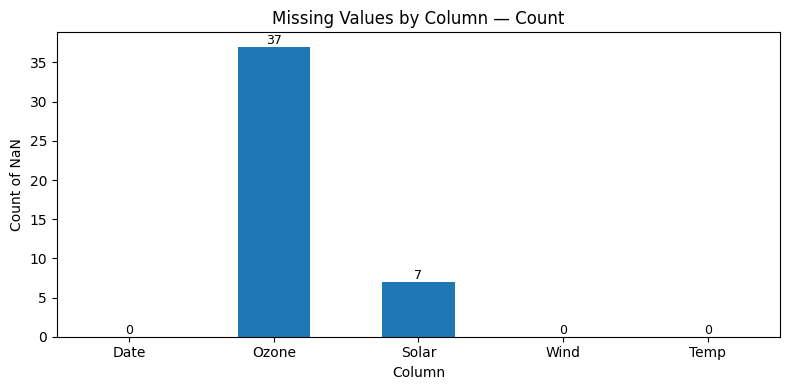

In [ ]:
# --- Bar chart of missing counts ---
ax = missing_summary["Missing_Count"].plot(kind="bar", figsize=(8,4), rot=0)
ax.set_title("Missing Values by Column — Count")
ax.set_ylabel("Count of NaN")
ax.set_xlabel("Column")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


#### **Visualize missingness (heatmap)**

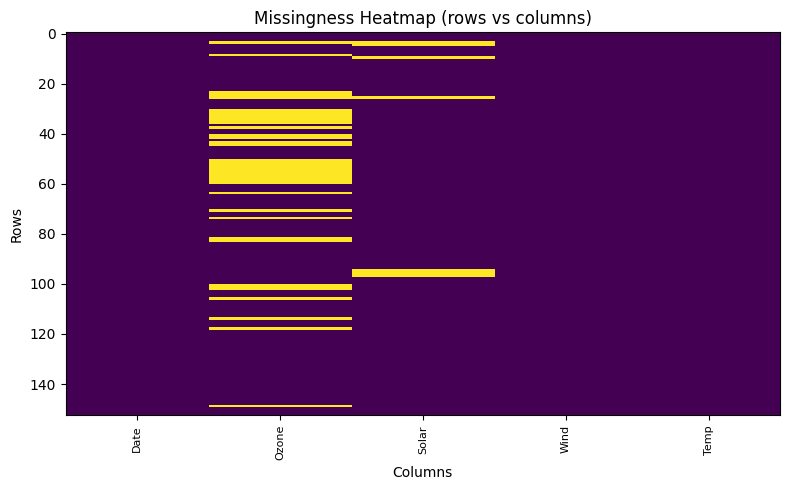

In [ ]:

# --- Heatmap of the missingness mask ---
fig, ax = plt.subplots(figsize=(8,5))
ax.imshow(df.isnull().values, aspect="auto", interpolation="nearest")
ax.set_title("Missingness Heatmap (rows vs columns)")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")
ax.set_xticks(range(df.shape[1]))
ax.set_xticklabels(df.columns, rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


#### **"Missingness correlation" (co-occurrence)**

Compute correlation of **missingness indicators** (1 if value is missing else 0).  
This shows whether missingness in one column tends to occur together with missingness in another.

In [ ]:
#  Missingness indicator correlation ---
null_ind = df.isnull().astype(int)
null_corr = null_ind.corr().round(2)
null_corr

,Date,Ozone,Solar,Wind,Temp
Date,NaN,NaN,NaN,NaN,NaN
Ozone,NaN,1.00,0.02,NaN,NaN
Solar,NaN,0.02,1.00,NaN,NaN
Wind,NaN,NaN,NaN,NaN,NaN
Temp,NaN,NaN,NaN,NaN,NaN


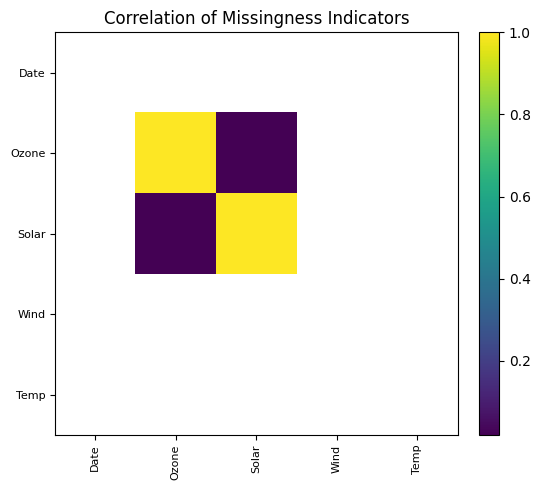

In [ ]:
# Heatmap of missingness correlation (matplotlib only) ---
fig, ax = plt.subplots(figsize=(6,5))
cax = ax.imshow(null_corr.values, interpolation="nearest")
ax.set_title("Correlation of Missingness Indicators")
ax.set_xticks(range(len(null_corr.columns)))
ax.set_yticks(range(len(null_corr.index)))
ax.set_xticklabels(null_corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(null_corr.index, fontsize=8)
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


#### **Handling strategies**

We'll demonstrate following strategies:
1. **Drop rows with any NaN**: `df.dropna()`  
2. **Impute** (fill) values:
   - Numeric: **mean**
3. **Forward/Backward fill** for time-like series

##### **Drop rows with any NaN**

In [ ]:
# Drop rows with any NaN ---
df_drop_rows = df.dropna()
print(df_drop_rows)

          Date  Ozone  Solar  Wind  Temp
0   1976-05-01   41.0  190.0   7.4    67
1   1976-05-02   36.0  118.0   8.0    72
2   1976-05-03   12.0  149.0  12.6    74
3   1976-05-04   18.0  313.0  11.5    62
6   1976-05-07   23.0  299.0   8.6    65
..         ...    ...    ...   ...   ...
147 1976-09-25   14.0   20.0  16.6    63
148 1976-09-26   30.0  193.0   6.9    70
150 1976-09-28   14.0  191.0  14.3    75
151 1976-09-29   18.0  131.0   8.0    76
152 1976-09-30   20.0  223.0  11.5    68

[111 rows x 5 columns]


In [ ]:
df_drop_rows.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111 entries, 0 to 152
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    111 non-null    datetime64[ns]
 1   Ozone   111 non-null    float64       
 2   Solar   111 non-null    float64       
 3   Wind    111 non-null    float64       
 4   Temp    111 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 5.2 KB


#### **Simple imputation**

In [ ]:
# Mean value of each colum
df.mean(numeric_only=True)

,0
Ozone,42.129310
Solar,185.931507
Wind,9.957516
Temp,77.882353


In [ ]:
# Simple imputation: mean for numeric
df_mean = df.fillna(df.mean(numeric_only=True))
print(df_mean)

          Date     Ozone       Solar  Wind  Temp
0   1976-05-01  41.00000  190.000000   7.4    67
1   1976-05-02  36.00000  118.000000   8.0    72
2   1976-05-03  12.00000  149.000000  12.6    74
3   1976-05-04  18.00000  313.000000  11.5    62
4   1976-05-05  42.12931  185.931507  14.3    56
..         ...       ...         ...   ...   ...
148 1976-09-26  30.00000  193.000000   6.9    70
149 1976-09-27  42.12931  145.000000  13.2    77
150 1976-09-28  14.00000  191.000000  14.3    75
151 1976-09-29  18.00000  131.000000   8.0    76
152 1976-09-30  20.00000  223.000000  11.5    68

[153 rows x 5 columns]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    153 non-null    datetime64[ns]
 1   Ozone   116 non-null    float64       
 2   Solar   146 non-null    float64       
 3   Wind    153 non-null    float64       
 4   Temp    153 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 6.1 KB


#### **Forward & Backward fill for time series data**

In [ ]:
# 4.4 Forward/Backward fill (for time-like data) ---
df_sorted = df.sort_values("Date").reset_index(drop=True)

ffill_ozone = df_sorted["Ozone"].ffill()
bfill_ozone = df_sorted["Ozone"].bfill()

# Compare small segment
comparison = pd.DataFrame({
    "Date": df_sorted["Date"],
    "Original_Ozone": df_sorted["Ozone"],
    "FFill_Ozone": ffill_ozone,
    "BFill_Ozone": bfill_ozone
}).head(10)

comparison

,Date,Original_Ozone,FFill_Ozone,BFill_Ozone
0,1976-05-01,41.0,41.0,41.0
1,1976-05-02,36.0,36.0,36.0
2,1976-05-03,12.0,12.0,12.0
3,1976-05-04,18.0,18.0,18.0
4,1976-05-05,NaN,18.0,28.0
5,1976-05-06,28.0,28.0,28.0
6,1976-05-07,23.0,23.0,23.0
7,1976-05-08,19.0,19.0,19.0
8,1976-05-09,8.0,8.0,8.0
9,1976-05-10,NaN,8.0,7.0


## **Outlier Detection & Treatment**
This section presents **detection** and **treatment** techniques for outliers in financial data

### **Detection Methods**

#### **Z-Score (Standard Score)**
Given observations $x_i$, mean $\mu$, and standard deviation $\sigma$, the **Z-score** is:

$$
z_i \,=\, \frac{x_i - \mu}{\sigma}
$$

A common rule-of-thumb flags **outliers** when $|z_i| > 3$.

In [ ]:
# --- Imports --- install first if required
import pandas as pd
from scipy import stats
import seaborn as sns

# Generate sample data
df = pd.DataFrame({
    "price": [
        # typical values ~90–115
        92.4, 105.8, 97.6, 110.2, 88.9, 101.5, 95.7, 112.3, 98.1, 93.6,
        108.7, 99.4, 104.3, 91.8, 96.2, 107.9, 102.6, 115.1, 89.7, 100.4,
        94.8, 106.1, 103.3, 97.2, 109.8, 90.5, 112.9, 99.8, 105.1, 93.1,
        98.9, 111.4, 101.9, 95.2, 107.1, 92.7, 113.6, 100.9, 96.8, 108.3,
        103.9, 94.2,
        # low outliers
        7.8, 11.2, 15.4,
        # high outliers
        280.0, 365.0, 430.0, 520.0, 770.0
    ]
})

In [ ]:
# Z-score method
z_scores = stats.zscore(df['price'])
outliers_z = df[abs(z_scores) > 3]
print(outliers_z)

    price
48  520.0
49  770.0


#### **IQR (Interquartile Range) Method**
Let:
- $Q_1$ = 25th percentile,  
- $Q_3$ = 75th percentile,  
- $\text{IQR} = Q_3 - Q_1$.

Define **fences**:
$$
\text{Lower Fence} = Q_1 - 1.5\times \text{IQR},\quad
\text{Upper Fence} = Q_3 + 1.5\times \text{IQR}
$$

Any observation outside these fences is flagged as an outlier by the IQR rule.


In [ ]:
# IQR method
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = df[(df['price'] < (Q1 - 1.5 * IQR)) | (df['price'] > (Q3 + 1.5 *IQR))]
print(outliers_iqr)

    price
42    7.8
43   11.2
44   15.4
45  280.0
46  365.0
47  430.0
48  520.0
49  770.0


#### **Visualization**
A **boxplot** provides a compact view of distribution, quartiles, and potential outliers (points beyond the whiskers).

<Axes: xlabel='price'>

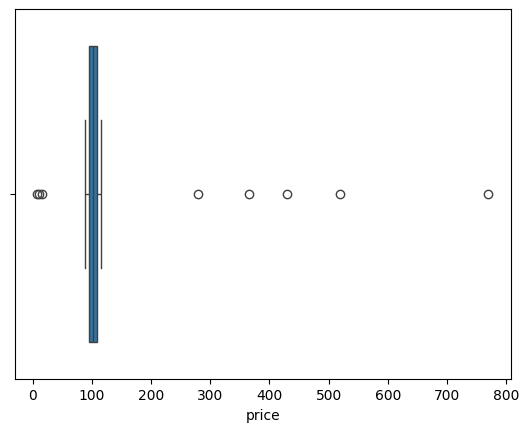

In [ ]:
# Visualization
sns.boxplot(x=df['price'])

### **Treatment Techniques**

Below are common approaches for handling outliers. Choose based on domain knowledge and model sensitivity.

#### **Winsorizing (Capping Extreme Values)**
**Winsorization** replaces the most extreme values with specific quantiles (here, the 5th and 95th percentiles).  
Conceptually, if $x < P_5$, set $x = P_5$; if $x > P_{95}$, set $x = P_{95}$.

In [ ]:
# Winsorizing (capping extreme values)
from scipy.stats.mstats import winsorize
# Winsorize at 5th and 95th percentiles
df['price_winsorized'] = winsorize(df['price'], limits=[0.05, 0.05])

df.tail(8)

,price,price_winsorized
42,7.8,15.4
43,11.2,15.4
44,15.4,15.4
45,280.0,280.0
46,365.0,365.0
47,430.0,430.0
48,520.0,430.0
49,770.0,430.0


#### **Log Transformation**
Apply a monotonic transform to reduce right-skew and compress large values:
$$
y \,=\, \log(x)
$$
**Note:** This requires strictly positive values; zeros/negatives will cause errors.

In [ ]:
# Log transformation
df['price_log'] = np.log(df['price'])

df.tail(10)

,price,price_winsorized,price_log
40,103.9,103.9,4.643429
41,94.2,94.2,4.545420
42,7.8,15.4,2.054124
43,11.2,15.4,2.415914
44,15.4,15.4,2.734368
45,280.0,280.0,5.634790
46,365.0,365.0,5.899897
47,430.0,430.0,6.063785
48,520.0,430.0,6.253829
49,770.0,430.0,6.646391


#### Remove Outliers (IQR Rule)
Filter data to **keep** only values within the IQR fences:
$$
Q_1 - 1.5\,\text{IQR} \le x \le Q_3 + 1.5\,\text{IQR}
$$


In [ ]:
# Remove outliers
df_clean = df[(df['price'] >= Q1 - 1.5 * IQR) & (df['price'] <= Q3 + 1.5 * IQR)]

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 42 entries, 0 to 41
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   42 non-null     float64
dtypes: float64(1)
memory usage: 672.0 bytes


#### Replace Flagged Outliers with the Median
Impute detected outliers using the median of the original series, preserving central tendency and robustness.

In [ ]:
# Replace with median
df.loc[outliers_iqr.index, 'price_median'] = df['price'].median()

df.tail(8)

,price,price_winsorized,price_log,price_median
42,7.8,15.4,2.054124,101.2
43,11.2,15.4,2.415914,101.2
44,15.4,15.4,2.734368,101.2
45,280.0,280.0,5.634790,101.2
46,365.0,365.0,5.899897,101.2
47,430.0,430.0,6.063785,101.2
48,520.0,430.0,6.253829,101.2
49,770.0,430.0,6.646391,101.2


## **Data Transformation for Financial Analysis**

This section focuses on **data transformations** commonly used in financial analytics.
We’ll generate a small, **synthetic dataset** (`price`, `volume`) and then apply:
- Min–Max normalization, Z-score standardization, and Robust scaling
- Log, log1p, square-root transforms
- Box–Cox (for strictly positive data) and Yeo–Johnson transforms

Each section includes short explanations and code so you can quickly adapt it to your own data.


In [ ]:
# import packages, install first if required
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, PowerTransformer
from scipy import stats

np.random.seed(42)  # reproducibility


In [ ]:
# --- Generate synthetic price (positive) with a few outliers ---
n = 60
# Base prices from a lognormal distribution (skewed, positive)
price_base = np.random.lognormal(mean=4.5, sigma=0.25, size=n)  # ~exp(4.5) ≈ 90 avg

# Inject a few large outliers
outlier_idx = np.random.choice(np.arange(n), size=4, replace=False)
price = price_base.copy()
price[outlier_idx] *= np.array([5, 7, 10, 12])  # amplify selected points

# --- Generate synthetic volume (counts), with zeros and outliers ---
volume_base = np.random.poisson(lam=600, size=n).astype(float)
# Set a few zeros to demonstrate log1p
zero_idx = np.random.choice(np.setdiff1d(np.arange(n), outlier_idx), size=5, replace=False)
volume = volume_base.copy()
volume[zero_idx] = 0

# Add some large spikes to emulate unusually active sessions
spike_idx = np.random.choice(np.setdiff1d(np.arange(n), np.union1d(outlier_idx, zero_idx)), size=3, replace=False)
volume[spike_idx] += np.array([5000, 8000, 12000])

# Assemble DataFrame (with an index that could represent days)
dates = pd.date_range(start='2024-01-01', periods=n, freq='D')
df = pd.DataFrame({'date': dates, 'price': price, 'volume': volume}).set_index('date')

df.head()


,price,volume
date,,
2024-01-01,101.919016,595.0
2024-01-02,86.958755,12630.0
2024-01-03,105.839324,0.0
2024-01-04,131.730407,579.0
2024-01-05,84.898944,588.0


### **Normalization & Scaling**

We demonstrate three popular scalers from `scikit-learn`:

- **Min–Max (0–1):** preserves shape but rescales to a fixed range; sensitive to outliers
- **Standard (Z-score):** centers to mean 0, std 1; still influenced by outliers
- **Robust:** uses median and IQR; **much less sensitive to outliers**

> In production, **fit** on training data and **transform** on validation/test data.


In [ ]:
features = ['price', 'volume']

# Min–Max Normalization (0–1)
minmax = MinMaxScaler()
X_minmax = pd.DataFrame(minmax.fit_transform(df[features]),
                        columns=[f'{c}_minmax' for c in features],
                        index=df.index)

# Z-score Standardization
standard = StandardScaler()
X_std = pd.DataFrame(standard.fit_transform(df[features]),
                     columns=[f'{c}_zscore' for c in features],
                     index=df.index)

# Robust Scaling
robust = RobustScaler()
X_rob = pd.DataFrame(robust.fit_transform(df[features]),
                     columns=[f'{c}_robust' for c in features],
                     index=df.index)

scaled = pd.concat([df, X_minmax, X_std, X_rob], axis=1)
scaled.head()

,price,volume,price_minmax,volume_minmax,price_zscore,volume_zscore,price_robust,volume_robust
date,,,,,,,,
2024-01-01,101.919016,595.0,0.045168,0.047110,-0.173215,-0.190472,0.463132,0.042254
2024-01-02,86.958755,12630.0,0.030720,1.000000,-0.254539,5.989989,-0.046971,339.056338
2024-01-03,105.839324,0.0,0.048955,0.000000,-0.151905,-0.496029,0.596803,-16.718310
2024-01-04,131.730407,579.0,0.073960,0.045843,-0.011161,-0.198689,1.479617,-0.408451
2024-01-05,84.898944,588.0,0.028730,0.046556,-0.265736,-0.194067,-0.117205,-0.154930


### **Log & Power Transformations**

- **Log transform** stabilizes variance and compresses the right tail (useful for prices).
- **log1p** is `log(1+x)` — safe for **zero** values (great for volumes).
- **Square root** is milder than log, sometimes used for counts.
- **Box–Cox** (strictly positive only) finds $\lambda$ to best normalize skew.
- **Yeo–Johnson** handles **zeros and negatives**; we’ll apply it to `price` here as an example.


In [ ]:
# Log transformations
df['log_price'] = np.log(df['price'])          # price > 0 required
df['log1p_volume'] = np.log1p(df['volume'])    # safe for zero volume
df['sqrt_price'] = np.sqrt(df['price'])

# Box–Cox on price (strictly positive)
boxcox_price, lambda_bc = stats.boxcox(df['price'].values)
df['boxcox_price'] = boxcox_price

# Yeo–Johnson (no positivity constraint)
pt = PowerTransformer(method='yeo-johnson')
df['yeojohnson_price'] = pt.fit_transform(df[['price']])

print(f'Box–Cox lambda (price): {lambda_bc:.4f}')
df[['price','log_price','log1p_volume','sqrt_price','boxcox_price','yeojohnson_price']].head()

Box–Cox lambda (price): -1.3874


,price,log_price,log1p_volume,sqrt_price,boxcox_price,yeojohnson_price
date,,,,,,
2024-01-01,101.919016,4.624179,6.390241,10.095495,0.719605,0.462984
2024-01-02,86.958755,4.465434,9.443909,9.325168,0.719314,-0.017812
2024-01-03,105.839324,4.661922,0.000000,10.287824,0.719665,0.562605
2024-01-04,131.730407,4.880757,6.363028,11.477387,0.719958,1.048018
2024-01-05,84.898944,4.441462,6.378426,9.214062,0.719265,-0.100009


### Quick Visual Checks

Simple histograms to **see** the effect of transformations.

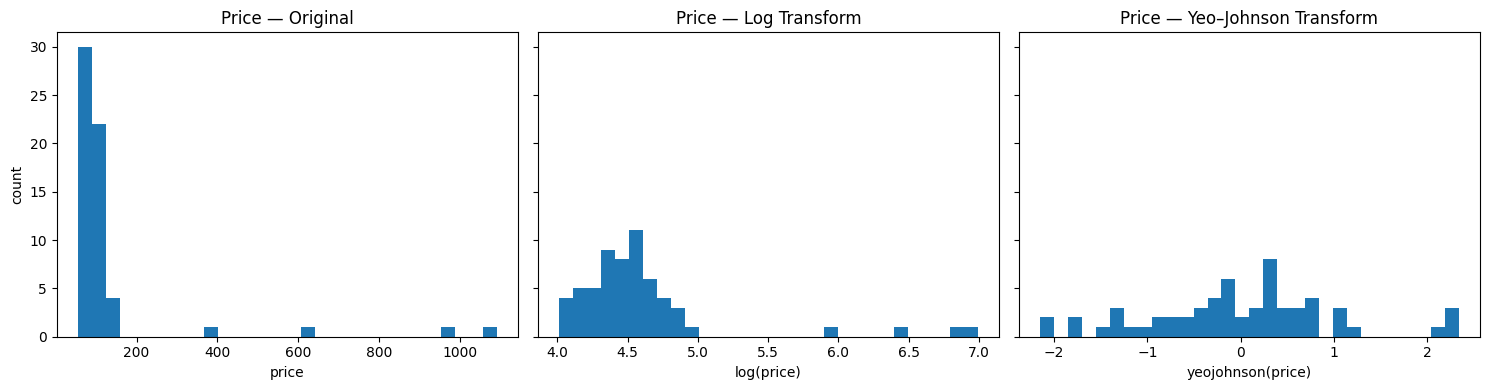

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(df['price'], bins=30)
axes[0].set_title('Price — Original')
axes[0].set_xlabel('price')
axes[0].set_ylabel('count')

axes[1].hist(df['log_price'], bins=30)
axes[1].set_title('Price — Log Transform')
axes[1].set_xlabel('log(price)')

axes[2].hist(df['yeojohnson_price'], bins=30)
axes[2].set_title('Price — Yeo–Johnson Transform')
axes[2].set_xlabel('yeojohnson(price)')

plt.tight_layout()
plt.show()

### Notes & Tips

- **Pipelines:** In real projects, wrap scalers/transforms in an `sklearn` `Pipeline` and keep train/test leakage in mind.
- **Inverse transforms:** Many transformers support `inverse_transform` to bring predictions back to the original scale.
- **Outliers:** Prefer **RobustScaler** or transform (log/yeo-johnson) before modeling.
- **Validation:** Always verify that transformations improve model performance and interpretability.


# Pipeline: transform (Yeo–Johnson) → standardize → linear regression
pipe = Pipeline([
    ("transform", PowerTransformer(method='yeo-johnson')),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

## **Reshaping Financial Data Structures**

This section demonstrates **reshaping techniques** in pandas:

- Pivot tables and melting (wide ↔ long)
- Cross-tabulations
- Stacking / Unstacking
- Transposing
- `wide_to_long` for multiple measures
- `explode` for list-like columns

Where helpful, we create purpose-built synthetic data to clearly show each operation.

In [ ]:
# import packages, install first if required
import numpy as np
import pandas as pd
np.random.seed(7)  # reproducibility

### **Create Synthetic Financial Data**

We’ll make a base **long-form** dataset with these columns:

- `date` — daily index
- `asset` — e.g., `STK_A`, `STK_B`, `BOND_C`
- `price`, `volume`
- `portfolio` — e.g., `Growth`, `Income`
- `sector` — e.g., `Tech`, `Finance`, `Energy`
- `risk_category` — e.g., `Low`, `Medium`, `High`

We also create **wide** datasets for melt and `wide_to_long`, and a **list-like** `transactions` column for `explode`.

In [ ]:
# --- Base long-form dataset ---
dates = pd.date_range('2024-03-01', periods=30, freq='D')
assets = ['STK_A', 'STK_B', 'BOND_C']
sectors = {'STK_A': 'Tech', 'STK_B': 'Finance', 'BOND_C': 'Energy'}
risk_levels = ['Low', 'Medium', 'High']

rows = []
for d in dates:
    for a in assets:
        price = np.round(np.random.lognormal(mean=4.6 if 'STK' in a else 4.2, sigma=0.18), 2)
        volume = int(np.random.poisson(lam=800 if 'STK' in a else 300))
        portfolio = 'Growth' if d.day % 2 == 0 else 'Income'
        sector = sectors[a]
        risk_category = np.random.choice(risk_levels, p=[0.3, 0.5, 0.2])
        rows.append([d, a, price, volume, portfolio, sector, risk_category])

df_long = pd.DataFrame(rows, columns=['date','asset','price','volume','portfolio','sector','risk_category'])
df_long = df_long.sort_values(['date','asset']).reset_index(drop=True)

# Preview
df_long.head()

,date,asset,price,volume,portfolio,sector,risk_category
0,2024-03-01,BOND_C,58.14,307,Income,Energy,High
1,2024-03-01,STK_A,88.44,806,Income,Tech,High
2,2024-03-01,STK_B,80.21,772,Income,Finance,Medium
3,2024-03-02,BOND_C,54.13,292,Growth,Energy,High
4,2024-03-02,STK_A,105.09,874,Growth,Tech,High


### **Pivot Tables (Long → Wide)**

Create a **price matrix** with dates as rows and assets as columns.


In [ ]:
pivot_df = df_long.pivot_table(
    index='date',
    columns='asset',
    values='price',
    aggfunc='mean'
)
pivot_df.head()

asset,BOND_C,STK_A,STK_B
date,,,
2024-03-01,58.14,88.44,80.21
2024-03-02,54.13,105.09,84.47
2024-03-03,65.51,94.93,103.72
2024-03-04,76.63,97.08,107.31
2024-03-05,74.65,98.01,100.79


In [ ]:
# Dimnesions
df_long.shape, pivot_df.shape

((90, 7), (30, 3))

### Melting (Wide → Long)

Create a small **wide** table with two assets as columns (`stock_a`, `stock_b`) plus `portfolio`.
Then **melt** it back to long format.


In [ ]:
# Make a three-column wide table from pivot (choose three assets)
df_wide = pivot_df[['STK_A', 'STK_B', 'BOND_C']].rename(
    columns={'STK_A': 'stock_a', 'STK_B': 'stock_b', 'BOND_C': 'bond_c'}
).reset_index()

df_wide['portfolio'] = np.where(df_wide['date'].dt.day % 2 == 0, 'Growth', 'Income')

df_wide.head()

asset,date,stock_a,stock_b,bond_c,portfolio
0,2024-03-01,88.44,80.21,58.14,Income
1,2024-03-02,105.09,84.47,54.13,Growth
2,2024-03-03,94.93,103.72,65.51,Income
3,2024-03-04,97.08,107.31,76.63,Growth
4,2024-03-05,98.01,100.79,74.65,Income


In [ ]:
# Wide to long
melted_df = pd.melt(
    df_wide,
    id_vars=['date', 'portfolio'],
    value_vars=['stock_a', 'stock_b', 'bond_c'],
    var_name='asset',
    value_name='price'
)
melted_df.head()

,date,portfolio,asset,price
0,2024-03-01,Income,stock_a,88.44
1,2024-03-02,Growth,stock_a,105.09
2,2024-03-03,Income,stock_a,94.93
3,2024-03-04,Growth,stock_a,97.08
4,2024-03-05,Income,stock_a,98.01


In [ ]:
# Dimensions
df_wide.shape, melted_df.shape

((30, 5), (90, 4))

### **Cross-Tabulation**

Frequency table of **sector** $×$ **risk_category** from the long-form data.


In [ ]:
crosstab = pd.crosstab(
    df_long['sector'],
    df_long['risk_category']
)
crosstab

risk_category,High,Low,Medium
sector,,,
Energy,6,10,14
Finance,7,7,16
Tech,10,9,11


### **Stacking / Unstacking (MultiIndex Columns)**

Build a multi-measure wide table (price & volume per asset) and use `stack` / `unstack` to move between axes.


In [ ]:
# Multi-measure wide (MultiIndex columns): top-level ['price','volume'], sub-level assets
multi_col_df = df_long.pivot_table(
    index='date',
    columns='asset',
    values=['price','volume'],
    aggfunc='mean'
)

multi_col_df.head(3)

price                 volume              
asset      BOND_C   STK_A   STK_B BOND_C  STK_A  STK_B
date                                                  
2024-03-01  59.59  134.87   91.48  289.0  800.0  800.0
2024-03-02  68.19   96.46  109.93  278.0  796.0  776.0
2024-03-03  58.34   92.79  143.34  304.0  774.0  798.0

In [ ]:
# Stack columns to rows → adds an extra index level (asset)
stacked_df = multi_col_df.stack(future_stack=True)  # stacks the last level by default
stacked_df.head(6)

price  volume
date       asset                 
2024-03-01 BOND_C   59.59   289.0
           STK_A   134.87   800.0
           STK_B    91.48   800.0
2024-03-02 BOND_C   68.19   278.0
           STK_A    96.46   796.0
           STK_B   109.93   776.0

In [ ]:
# Reverse: rows back to columns
unstacked_df = stacked_df.unstack()
unstacked_df.head(3)

price                 volume              
asset      BOND_C   STK_A   STK_B BOND_C  STK_A  STK_B
date                                                  
2024-03-01  59.59  134.87   91.48  289.0  800.0  800.0
2024-03-02  68.19   96.46  109.93  278.0  796.0  776.0
2024-03-03  58.34   92.79  143.34  304.0  774.0  798.0

### **Transpose**

Quickly flip rows and columns. Useful for certain reporting or quick inspection.


In [ ]:
transposed_df = pivot_df.head(5).T
transposed_df


date,2024-03-01,2024-03-02,2024-03-03,2024-03-04,2024-03-05
asset,,,,,
BOND_C,58.14,54.13,65.51,76.63,74.65
STK_A,88.44,105.09,94.93,97.08,98.01
STK_B,80.21,84.47,103.72,107.31,100.79


### `wide_to_long` (Multiple Measures)

Create columns like `price_A`, `volume_A`, `price_B`, `volume_B` for two assets, then reshape to long with a single call.


In [ ]:
# Build a small wide table with stubnames price_*, volume_* (A/B)
tmp = df_long[df_long['asset'].isin(['STK_A','STK_B'])].pivot_table(
    index='date',
    columns='asset',
    values=['price','volume'],
    aggfunc='mean'
)

# Flatten columns to 'price_STK_A', etc., then rename to _A/_B so sep='_' splits nicely
tmp.columns = [f'{lvl0}_{lvl1}' for lvl0, lvl1 in tmp.columns]
rename_map = {
    'price_STK_A':'price_A', 'volume_STK_A':'volume_A',
    'price_STK_B':'price_B', 'volume_STK_B':'volume_B'
}
df_wtl = tmp.rename(columns=rename_map).reset_index()
df_wtl.head()

,date,price_A,price_B,volume_A,volume_B
0,2024-03-01,88.44,80.21,806.0,772.0
1,2024-03-02,105.09,84.47,874.0,797.0
2,2024-03-03,94.93,103.72,778.0,805.0
3,2024-03-04,97.08,107.31,778.0,793.0
4,2024-03-05,98.01,100.79,800.0,791.0


In [ ]:
df_wtl.shape

(30, 5)

In [ ]:
# Reshape wide → long across both 'price' and 'volume' simultaneously
long_multi = (
    pd.wide_to_long(
        df_wtl,
        stubnames=['price', 'volume'],
        i='date',
        j='asset',
        sep='_',
        suffix='[A-Z]+'   # <-- match letter suffixes like A, B, etc.
    )
    .reset_index()
    .sort_values(['date', 'asset'])
)

long_multi.head()

,date,asset,price,volume
0,2024-03-01,A,88.44,806.0
30,2024-03-01,B,80.21,772.0
1,2024-03-02,A,105.09,874.0
31,2024-03-02,B,84.47,797.0
2,2024-03-03,A,94.93,778.0


### Exploding List-like Columns

Sometimes a cell contains a **list of transactions** for a date/portfolio. `explode` turns each list element into its own row.


In [ ]:
# Create a compact 'transactions' table with list-like values
tx_dates = pd.date_range('2024-03-05', periods=6, freq='D')
portfolios = ['Income','Growth']
rows = []
for d in tx_dates:
    for p in portfolios:
        n = np.random.randint(1, 5)  # 1–4 transactions
        amounts = list(np.round(np.random.uniform(100, 2000, size=n), 2))
        rows.append([d, p, amounts])

df_tx = pd.DataFrame(rows, columns=['date','portfolio','transactions'])
df_tx.head()


,date,portfolio,transactions
0,2024-03-05,Income,[898.71]
1,2024-03-05,Growth,"[550.72, 845.71, 1756.19, 907.41]"
2,2024-03-06,Income,"[1815.83, 746.27]"
3,2024-03-06,Growth,"[594.68, 106.41, 1186.99]"
4,2024-03-07,Income,[426.21]


In [ ]:
# Explode
exploded_df = df_tx.explode('transactions', ignore_index=True)
exploded_df.head()

,date,portfolio,transactions
0,2024-03-05,Income,898.71
1,2024-03-05,Growth,550.72
2,2024-03-05,Growth,845.71
3,2024-03-05,Growth,1756.19
4,2024-03-05,Growth,907.41
